In [1]:
import numpy as np
import pandas as pd

from tqdm import tqdm

from transformers import pipeline

from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

from sklearn.model_selection import TimeSeriesSplit

In [2]:
wti = pd.read_csv(
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\wti_v2.csv",
    parse_dates=["timestamp_utc"]
)

tweets = pd.read_csv(
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\tweets_v2.csv",
    parse_dates=["timestamp_utc"]
)

wti = wti.sort_values("timestamp_utc")
tweets = tweets.sort_values("timestamp_utc")

wti["timestamp"] = pd.to_datetime(wti["timestamp_utc"], utc=True)
tweets["timestamp"] = pd.to_datetime(tweets["timestamp_utc"], utc=True)

In [3]:
finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    truncation=True
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\02_Florian_Benutzer\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [4]:
def finbert_score(text):

    try:
        result = finbert(text[:512])[0]

        label = result["label"].lower()
        score = result["score"]

        if label == "positive":
            return score

        elif label == "negative":
            return -score

        return 0.0

    except:
        return np.nan

In [5]:
tqdm.pandas()

tweets["sentiment_score"] = tweets["text"].progress_apply(
    finbert_score
)

100%|██████████| 46694/46694 [1:06:41<00:00, 11.67it/s]


In [6]:
tweets["tweet_length"] = tweets["text"].str.len()

tweets["num_hashtags"] = tweets["text"].str.count("#")

tweets["num_mentions"] = tweets["text"].str.count("@")

tweets["num_urls"] = tweets["text"].str.contains(
    "http",
    regex=False
).astype(int)

In [7]:
wti = wti.set_index("timestamp")

In [8]:
wti["ret_1m"] = np.log(
    wti["close"] / wti["close"].shift(1)
)

wti["ret_5m"] = np.log(
    wti["close"] / wti["close"].shift(5)
)

wti["ret_15m"] = np.log(
    wti["close"] / wti["close"].shift(15)
)

wti["ret_30m"] = np.log(
    wti["close"] / wti["close"].shift(30)
)

wti["ret_60m"] = np.log(
    wti["close"] / wti["close"].shift(60)
)

In [9]:
wti["vol_5m"] = (
    wti["ret_1m"]
    .rolling(5)
    .std()
)

wti["vol_15m"] = (
    wti["ret_1m"]
    .rolling(15)
    .std()
)

wti["vol_60m"] = (
    wti["ret_1m"]
    .rolling(60)
    .std()
)

In [10]:
wti["mom_5m"] = (
    wti["close"] /
    wti["close"].shift(5)
) - 1

wti["mom_15m"] = (
    wti["close"] /
    wti["close"].shift(15)
) - 1

wti["mom_60m"] = (
    wti["close"] /
    wti["close"].shift(60)
) - 1

In [11]:
wti["hl_spread"] = (
    wti["high"] -
    wti["low"]
) / wti["close"]

wti["oc_return"] = (
    wti["close"] -
    wti["open"]
) / wti["open"]

In [12]:
wti["hour"] = wti.index.hour

wti["dayofweek"] = wti.index.dayofweek

In [29]:
HORIZON = 5

In [30]:
market_features = [
    "ret_1m",
    "ret_5m",
    "ret_15m",
    "ret_30m",
    "ret_60m",
    "vol_5m",
    "vol_15m",
    "vol_60m",
    "mom_5m",
    "mom_15m",
    "mom_60m",
    "hl_spread",
    "oc_return",
    "hour",
    "dayofweek"
]

In [31]:
rows = []

for _, tweet in tqdm(
    tweets.iterrows(),
    total=len(tweets)
):

    t = tweet["timestamp"].floor("min")

    if t not in wti.index:
        continue

    future_time = t + pd.Timedelta(
        minutes=HORIZON
    )

    if future_time not in wti.index:
        continue

    current_price = wti.loc[t, "close"]
    future_price = wti.loc[future_time, "close"]

    target = int(
        future_price > current_price
    )

    row = {}

    row["timestamp"] = t
    row["target"] = target

    for col in market_features:
        row[col] = wti.loc[t, col]

    row["sentiment_score"] = tweet[
        "sentiment_score"
    ]

    row["tweet_length"] = tweet[
        "tweet_length"
    ]

    row["num_hashtags"] = tweet[
        "num_hashtags"
    ]

    row["num_mentions"] = tweet[
        "num_mentions"
    ]

    row["num_urls"] = tweet[
        "num_urls"
    ]

    rows.append(row)

  0%|          | 0/46694 [00:00<?, ?it/s]

100%|██████████| 46694/46694 [00:30<00:00, 1523.06it/s]


In [32]:
event_df = pd.DataFrame(rows)

In [33]:
event_df = event_df.dropna()

In [34]:
baseline_features = market_features

In [35]:
twitter_features = (
    market_features +
    [
        "sentiment_score",
        "tweet_length",
        "num_hashtags",
        "num_mentions",
        "num_urls"
    ]
)

In [36]:
event_df = event_df.sort_values(
    "timestamp"
)

In [37]:
X_base = event_df[
    baseline_features
]

X_twitter = event_df[
    twitter_features
]

y = event_df["target"]

In [38]:
def create_model():

    return XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )

In [39]:
tscv = TimeSeriesSplit(
    n_splits=5
)

In [40]:
baseline_auc = []
twitter_auc = []

In [41]:
for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X_base)
):

    X_train_base = X_base.iloc[train_idx]
    X_test_base = X_base.iloc[test_idx]

    X_train_tw = X_twitter.iloc[train_idx]
    X_test_tw = X_twitter.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    baseline_model = create_model()

    baseline_model.fit(
        X_train_base,
        y_train
    )

    prob_base = baseline_model.predict_proba(
        X_test_base
    )[:, 1]

    auc_base = roc_auc_score(
        y_test,
        prob_base
    )

    baseline_auc.append(
        auc_base
    )

    twitter_model = create_model()

    twitter_model.fit(
        X_train_tw,
        y_train
    )

    prob_tw = twitter_model.predict_proba(
        X_test_tw
    )[:, 1]

    auc_tw = roc_auc_score(
        y_test,
        prob_tw
    )

    twitter_auc.append(
        auc_tw
    )

    print(
        f"Fold {fold+1}"
    )

    print(
        f"Baseline AUC: {auc_base:.4f}"
    )

    print(
        f"Twitter AUC : {auc_tw:.4f}"
    )

    print(
        f"Delta       : {auc_tw-auc_base:.4f}"
    )

    print()

Fold 1
Baseline AUC: 0.5080
Twitter AUC : 0.5068
Delta       : -0.0013

Fold 2
Baseline AUC: 0.5259
Twitter AUC : 0.5333
Delta       : 0.0075

Fold 3
Baseline AUC: 0.5220
Twitter AUC : 0.5250
Delta       : 0.0030

Fold 4
Baseline AUC: 0.5296
Twitter AUC : 0.5198
Delta       : -0.0099

Fold 5
Baseline AUC: 0.5302
Twitter AUC : 0.5275
Delta       : -0.0026



In [42]:
print(
    "BASELINE MEAN AUC:",
    np.mean(baseline_auc)
)

print(
    "TWITTER MEAN AUC:",
    np.mean(twitter_auc)
)

print(
    "DELTA:",
    np.mean(twitter_auc)
    -
    np.mean(baseline_auc)
)

BASELINE MEAN AUC: 0.5231515107711415
TWITTER MEAN AUC: 0.5224801576597926
DELTA: -0.0006713531113489157


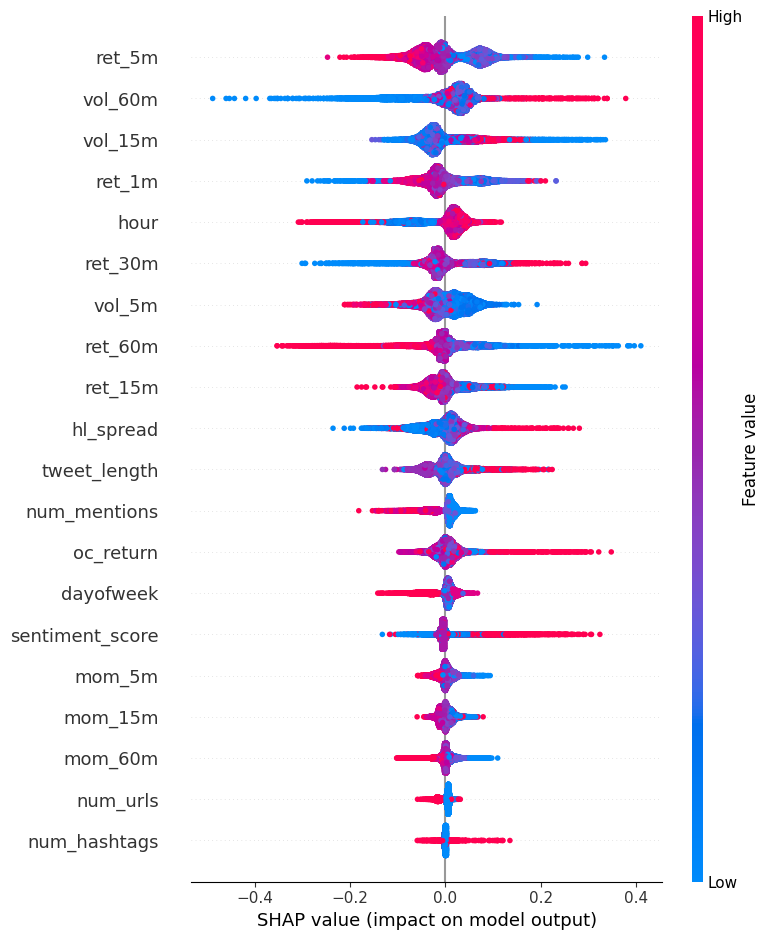

In [43]:
import shap

twitter_model.fit(
    X_twitter,
    y
)

explainer = shap.TreeExplainer(
    twitter_model
)

shap_values = explainer.shap_values(
    X_twitter
)

shap.summary_plot(
    shap_values,
    X_twitter
)